# WELCOME TO CRESENCIO'S LAB 7: DATA VISUALIZATION

**START OF LAB 7 SETUP AND PROCEDURE**

**LAB 7 SETUP**

In [76]:
# PROCEDURE 1: Install Libraries and Load Dataset from Kaggle
# Option A — Manual Download

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

kaggle_dir = os.path.expanduser("~/.kaggle")
if not os.path.exists(kaggle_dir):
    os.makedirs(kaggle_dir)

In [77]:
# PROCEDURE 2: Load and Preprocess the Dataset
import pandas as pd
import os

# Step 1: Define the path to your CSV file
# Update the path below to match where you saved your CSV file
dataset_path = "/home/Centaurids/Documents/Computer Programming/Lab7_Data_Visualization/Lab7_Data_Visualization/spotify_top_1000_tracks.csv"
# Example for Mac/Linux:
# dataset_path = "/home/yourname/activity7/spotify_top_1000_tracks.csv"

# Step 2: Load the dataset
df = pd.read_csv(dataset_path, encoding="utf-8")

# Step 3: Convert release_date to datetime and extract year
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year

# Note: 'duration_min' already exists in the CSV — no need to create it manually.

# Step 4: Preview the loaded data
print("Dataset loaded and basic preprocessing complete!")
print(df.head(3))

Dataset loaded and basic preprocessing complete!
                 track_name          artist  \
0  All The Stars (with SZA)  Kendrick Lamar   
1                   Starboy      The Weeknd   
2                  Señorita    Shawn Mendes   

                                               album release_date  popularity  \
0  Black Panther The Album Music From And Inspire...   2018-02-09          95   
1                                            Starboy   2016-11-25          90   
2                                           Señorita   2019-06-21          80   

                                         spotify_url                      id  \
0  https://open.spotify.com/track/3GCdLUSnKSMJhs4...  3GCdLUSnKSMJhs4Tj6CV3s   
1  https://open.spotify.com/track/7MXVkk9YMctZqd1...  7MXVkk9YMctZqd1Srtv4MB   
2  https://open.spotify.com/track/0TK2YIli7K1leLo...  0TK2YIli7K1leLovkQiNik   

   duration_min    year  
0      3.869767  2018.0  
1      3.840883  2016.0  
2      3.182667  2019.0  


In [78]:
# STEP 3: Data Cleaning and Feature Engineering

import numpy as np

# Step 1: Clean up text columns (strip leading/trailing whitespace)
df['track_name'] = df['track_name'].str.strip()
df['artist']     = df['artist'].str.strip()
df['album']      = df['album'].str.strip()

# Step 2: Convert 'year' to integer (fill missing with 0 first)
df['year'] = df['year'].fillna(0).astype(int)

# Step 3: Drop unnecessary columns
cols_to_drop = ['spotify_url', 'id', 'release_date']

if 'time_signature' in df.columns:
    cols_to_drop.append('time_signature')
if 'key' in df.columns:
    cols_to_drop.append('key')
if 'mode' in df.columns:
    cols_to_drop.append('mode')

df = df.drop(columns=cols_to_drop, errors='ignore')

# Step 4: Feature Engineering — Tempo Category
tempo_bins   = [0, 100, 140, np.inf]
tempo_labels = ['Slow', 'Medium', 'Fast']

if 'tempo' in df.columns:
    df['tempo_category'] = pd.cut(
        df['tempo'],
        bins=tempo_bins,
        labels=tempo_labels,
        right=False
    )
    print("Feature 'tempo_category' created.")
else:
    print("Warning: 'tempo' column not found; skipping 'tempo_category' creation.")

# Step 5: Remove duplicate tracks
df = df.drop_duplicates(subset=['track_name', 'artist'], keep='first')

print(f"Data cleaning and feature engineering complete.")
print(f"Final Row Count after deduplication: {len(df)}")

Data cleaning and feature engineering complete.
Final Row Count after deduplication: 971


**PROCEDURES AND TRY IT SOLUTION FOR LAB 7**

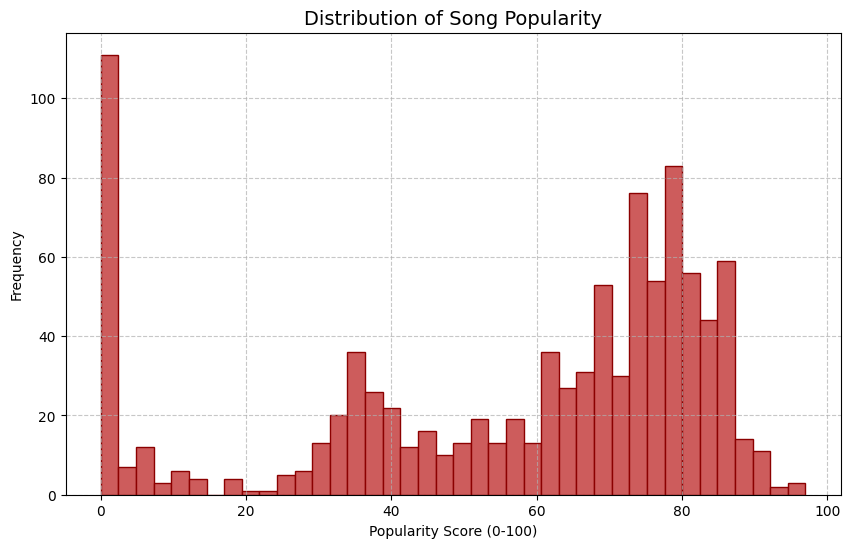

In [79]:
# PROCEDURE 1: Histogram — Distribution of Song Popularity
# Shows the frequency distribution of popularity scores across all songs.

import matplotlib.pyplot as plt

# Step 1: Create the figure
plt.figure(figsize=(10, 6))

# Step 2: Plot the histogram using 'popularity' column
plt.hist(df['popularity'], bins=40, color='indianred', edgecolor='darkred')

# Step 3: Add labels and formatting
plt.title('Distribution of Song Popularity', fontsize=14)
plt.xlabel('Popularity Score (0-100)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)

# Step 4: Display the chart
plt.show()

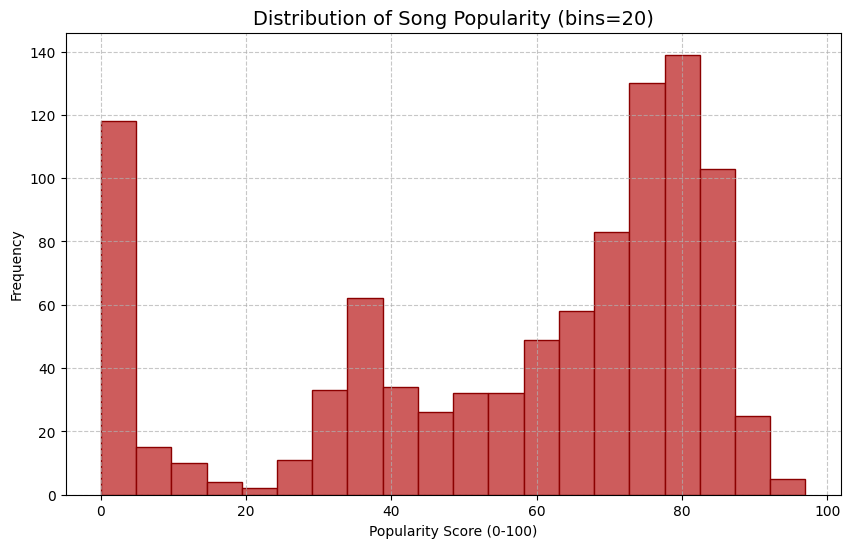

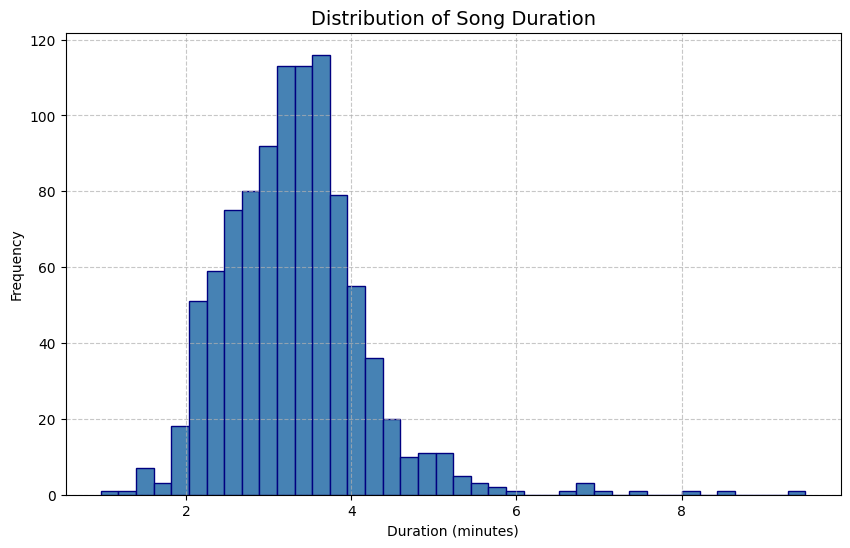

In [80]:
# TRY IT — Procedure 1: Experiment with bin count and different columns

import matplotlib.pyplot as plt

# Try It 1: Change the number of bins (try 20, 50, or 80) and observe smoothness
plt.figure(figsize=(10, 6))
plt.hist(df['popularity'], bins=20, color='indianred', edgecolor='darkred')
plt.title('Distribution of Song Popularity (bins=20)', fontsize=14)
plt.xlabel('Popularity Score (0-100)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Try It 2: Replace 'popularity' with 'duration_min' to see duration distribution
plt.figure(figsize=(10, 6))
plt.hist(df['duration_min'], bins=40, color='steelblue', edgecolor='navy')
plt.title('Distribution of Song Duration', fontsize=14)
plt.xlabel('Duration (minutes)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

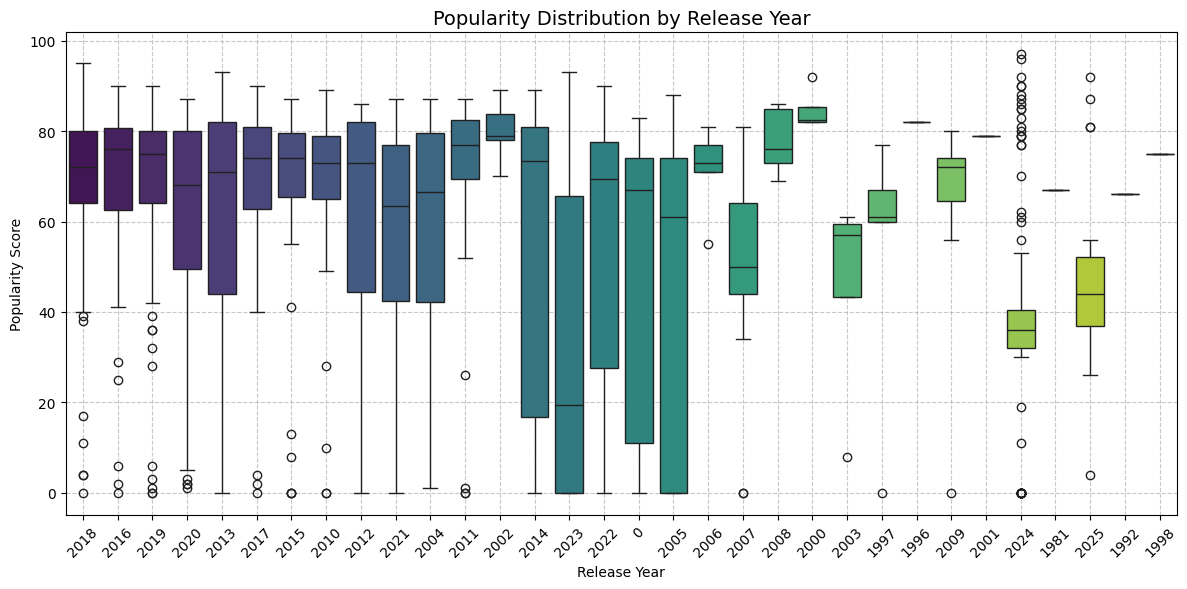

In [81]:
# PROCEDURE 2: Boxplot — Popularity Distribution by Release Year (Fixed)
# Shows how popularity scores are spread across songs from different release years.

import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Convert year to string for proper categorical hue
df['year_str'] = df['year'].astype(str)

# Step 2: Create the figure
plt.figure(figsize=(12, 6))

# Step 3: Draw boxplot grouped by release year
sns.boxplot(
    x='year_str',
    y='popularity',
    hue='year_str',    # Fix: explicitly assign hue to remove deprecation warning
    data=df,
    palette='viridis',
    legend=False       # Fix: suppress redundant legend since hue mirrors x-axis
)

# Step 4: Add labels and formatting
plt.title('Popularity Distribution by Release Year', fontsize=14)
plt.xlabel('Release Year')
plt.ylabel('Popularity Score')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)

# Step 5: Display the chart
plt.tight_layout()
plt.show()

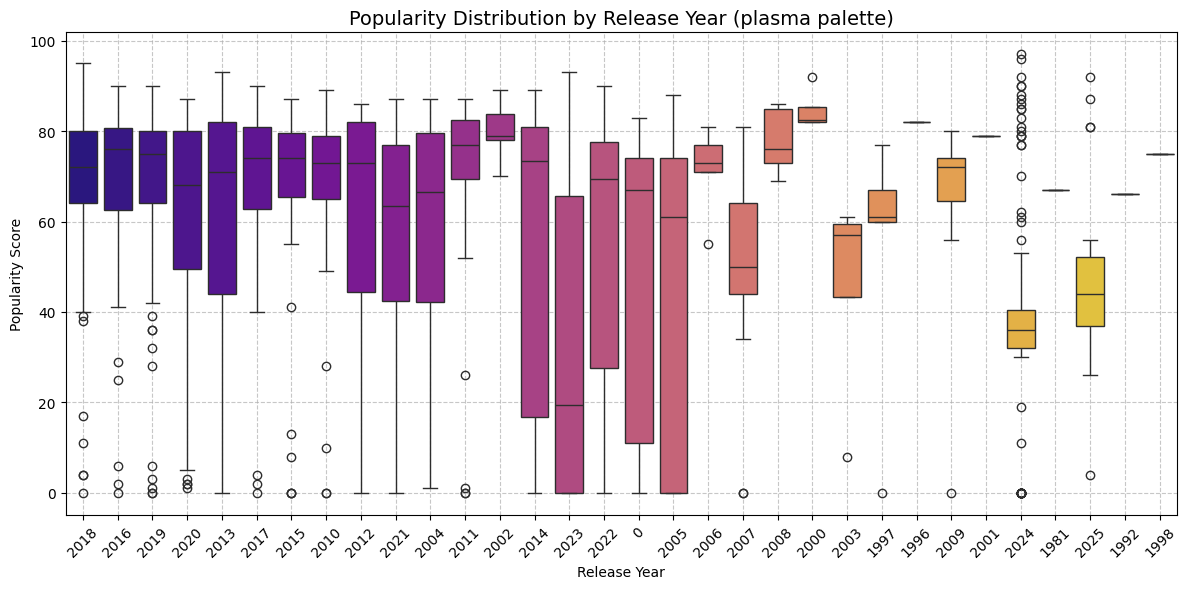

In [82]:
# TRY IT — Procedure 2: Change the color palette (Fixed)

import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Convert year to string for proper categorical hue
df['year_str'] = df['year'].astype(str)

# Step 2: Try changing 'plasma' to 'magma' or 'viridis' to experiment
plt.figure(figsize=(12, 6))
sns.boxplot(
    x='year_str',
    y='popularity',
    hue='year_str',    # Fix: explicitly assign hue to remove deprecation warning
    data=df,
    palette='plasma',
    legend=False       # Fix: suppress redundant legend since hue mirrors x-axis
)

# Step 3: Add labels and formatting
plt.title('Popularity Distribution by Release Year (plasma palette)', fontsize=14)
plt.xlabel('Release Year')
plt.ylabel('Popularity Score')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

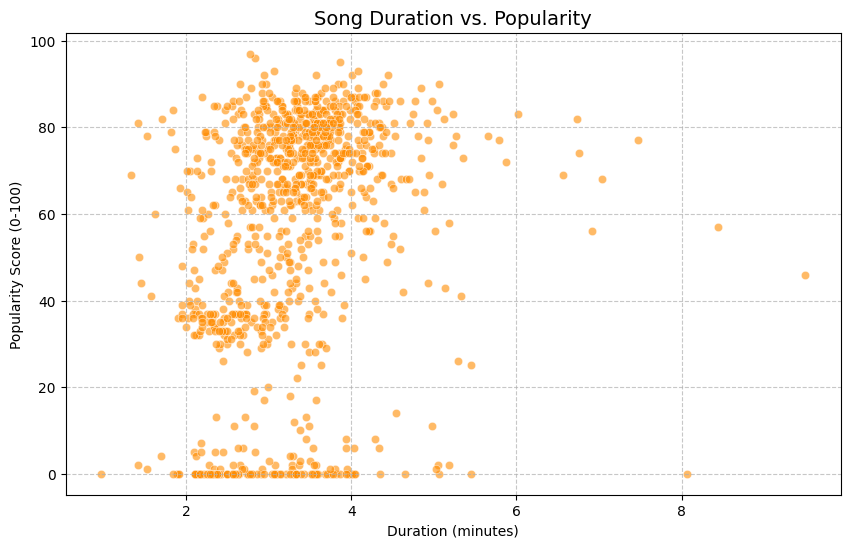

In [83]:
# PROCEDURE 3: Scatter Plot — Song Duration vs. Popularity
# Shows the relationship between how long a song is and its popularity score.

import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Create the figure
plt.figure(figsize=(10, 6))

# Step 2: Draw the scatter plot
sns.scatterplot(x='duration_min', y='popularity', data=df, alpha=0.6, color='darkorange')

# Step 3: Add labels and formatting
plt.title('Song Duration vs. Popularity', fontsize=14)
plt.xlabel('Duration (minutes)')
plt.ylabel('Popularity Score (0-100)')
plt.grid(True, linestyle='--', alpha=0.7)

# Step 4: Display the chart
plt.show()

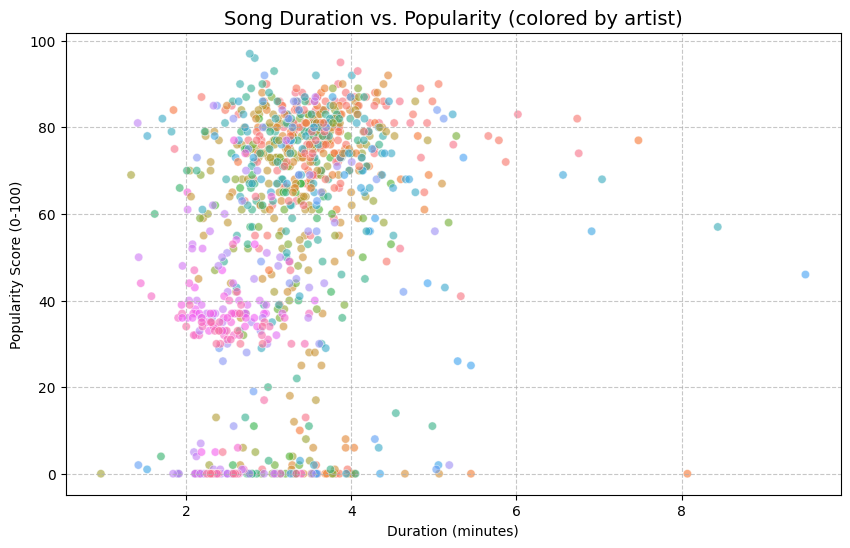

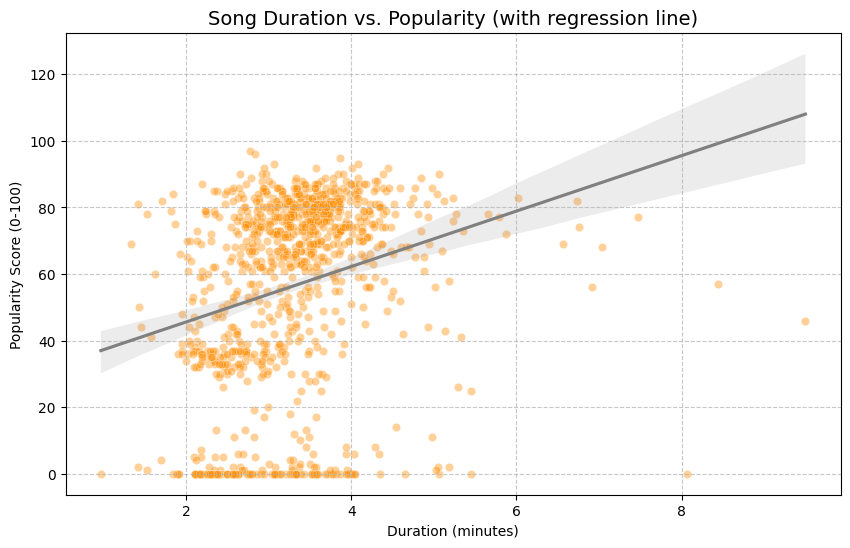

In [84]:
# TRY IT — Procedure 3: Color by artist and add a regression line

import matplotlib.pyplot as plt
import seaborn as sns

# Try It 1: Color-code points by artist using hue
plt.figure(figsize=(10, 6))
sns.scatterplot(x='duration_min', y='popularity', data=df, alpha=0.6, hue='artist', legend=False)
plt.title('Song Duration vs. Popularity (colored by artist)', fontsize=14)
plt.xlabel('Duration (minutes)')
plt.ylabel('Popularity Score (0-100)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Try It 2: Add a regression trend line on top of the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='duration_min', y='popularity', data=df, alpha=0.4, color='darkorange')
sns.regplot(x='duration_min', y='popularity', data=df, scatter=False, color='grey')
plt.title('Song Duration vs. Popularity (with regression line)', fontsize=14)
plt.xlabel('Duration (minutes)')
plt.ylabel('Popularity Score (0-100)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

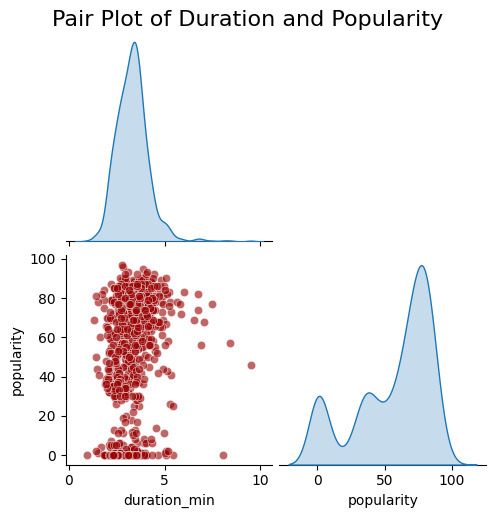

In [85]:
# PROCEDURE 4: Pair Plot — Feature Relationships Overview
# Shows pairwise relationships and individual distributions for duration and popularity.

import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Select the two confirmed numerical columns
key_features = ['duration_min', 'popularity']

# Step 2: Draw the pair plot
sns.pairplot(
    df[key_features],
    diag_kind='kde',
    corner=True,
    plot_kws={'alpha': 0.6, 'color': '#990000'}
)

# Step 3: Add a title and display
plt.suptitle('Pair Plot of Duration and Popularity', y=1.02, fontsize=16)
plt.show()

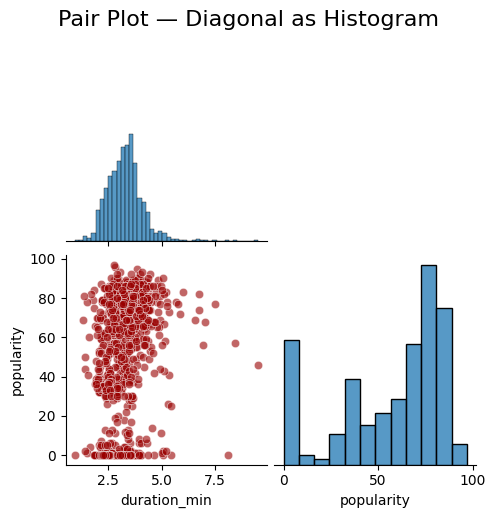

In [86]:
# TRY IT — Procedure 4: Change the diagonal plot type

import matplotlib.pyplot as plt
import seaborn as sns

# Try changing diag_kind from 'kde' to 'hist' to see histograms on the diagonal
key_features = ['duration_min', 'popularity']

sns.pairplot(
    df[key_features],
    diag_kind='hist',
    corner=True,
    plot_kws={'alpha': 0.6, 'color': '#990000'}
)
plt.suptitle('Pair Plot — Diagonal as Histogram', y=1.02, fontsize=16)
plt.show()

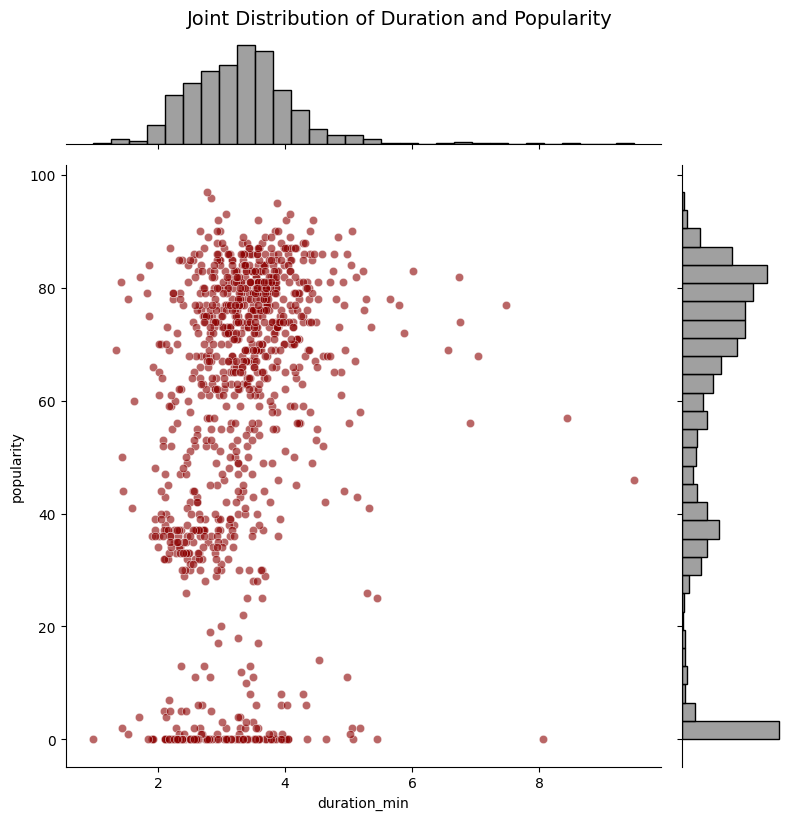

In [87]:
# PROCEDURE 5: Joint Plot — Duration vs. Popularity Distribution
# Shows the relationship between duration and popularity along with each variable's
# individual distribution on the margins.

import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Draw the joint plot
sns.jointplot(
    x='duration_min',
    y='popularity',
    data=df,
    kind='scatter',
    height=8,
    marginal_kws={'bins': 30, 'color': 'gray', 'edgecolor': 'black'},
    joint_kws={'alpha': 0.6, 'color': 'darkred'}
)

# Step 2: Add a title and display
plt.suptitle('Joint Distribution of Duration and Popularity', y=1.02, fontsize=14)
plt.show()

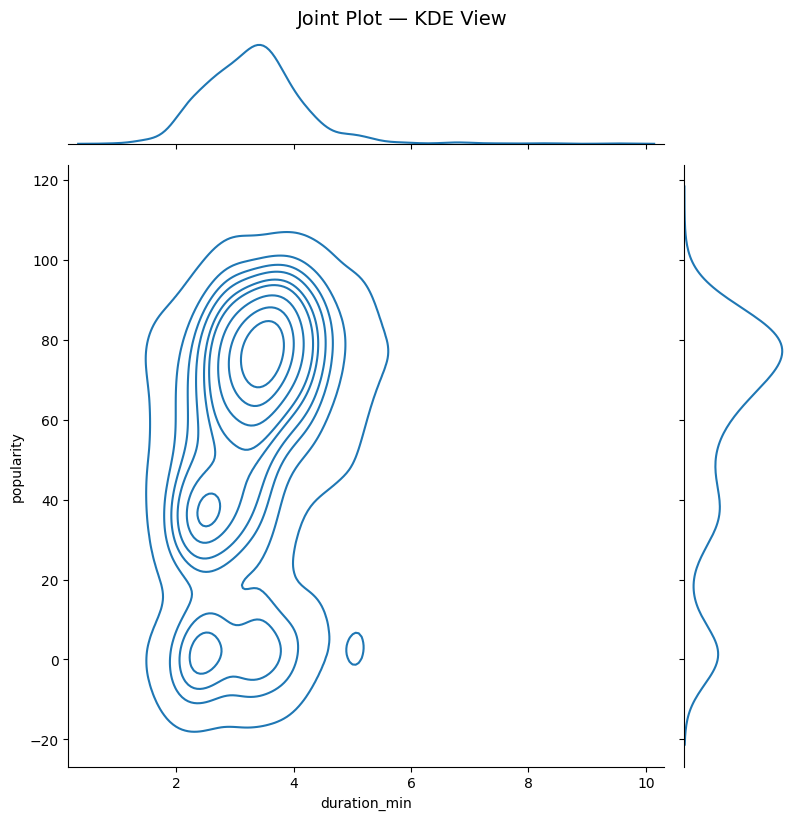

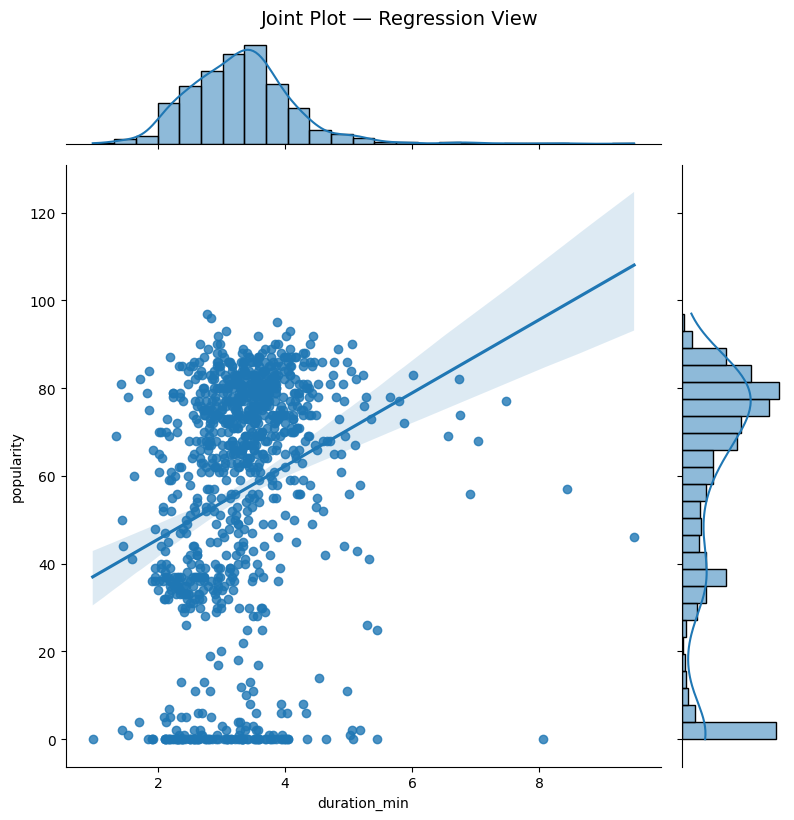

In [88]:
# TRY IT — Procedure 5: Change plot kind and adjust marginal histograms

import matplotlib.pyplot as plt
import seaborn as sns

# Try It 1: Change kind to 'kde' for a smooth density view
sns.jointplot(
    x='duration_min',
    y='popularity',
    data=df,
    kind='kde',
    height=8
)
plt.suptitle('Joint Plot — KDE View', y=1.02, fontsize=14)
plt.show()

# Try It 2: Change kind to 'reg' for scatter + regression
sns.jointplot(
    x='duration_min',
    y='popularity',
    data=df,
    kind='reg',
    height=8,
    marginal_kws=dict(bins=25)
)
plt.suptitle('Joint Plot — Regression View', y=1.02, fontsize=14)
plt.show()

In [89]:
# PROCEDURE 6: Animated Line Chart — Evolution of Average Popularity Over Time
# Creates an animated GIF showing how average track popularity changes year by year.

import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# Step 1: Load the dataset (update path to match your file location)
csv_file = r"/home/Centaurids/Documents/Computer Programming/Lab7_Data_Visualization/Lab7_Data_Visualization/spotify_top_1000_tracks.csv"
df_anim = pd.read_csv(csv_file)

# Step 2: Data Preparation
df_anim['release_date'] = pd.to_datetime(df_anim['release_date'], errors='coerce')
df_anim['year'] = df_anim['release_date'].dt.year
df_anim = df_anim.dropna(subset=['year'])

# Compute average popularity per year
yearly_popularity = df_anim.groupby('year')['popularity'].mean().reset_index()
yearly_popularity = yearly_popularity.sort_values('year')

# Step 3: Initialize the Figure
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(yearly_popularity['year'].min(), yearly_popularity['year'].max())
ax.set_ylim(0, yearly_popularity['popularity'].max() * 1.1)
line, = ax.plot([], [], color='royalblue', linewidth=2.5, label='Average Popularity')
ax.set_title("Evolution of Track Popularity Over Time", fontsize=14, color='navy')
ax.set_xlabel("Year of Release", fontsize=12)
ax.set_ylabel("Average Popularity", fontsize=12)
ax.legend(loc="upper left")
plt.tight_layout()

# Step 4: Define the Animation Function
def animate(i):
    x = yearly_popularity['year'][:i]
    y = yearly_popularity['popularity'][:i]
    line.set_data(x, y)
    return line,

# Step 5: Create and Save the Animation as a GIF
ani = FuncAnimation(fig, animate, frames=len(yearly_popularity), interval=100, repeat=False)

gif_path = os.path.abspath("yearly_popularity_trend.gif")
ani.save(gif_path, writer=PillowWriter(fps=10))
print(f"GIF saved successfully at: {gif_path}")

# Step 6: Open the saved GIF automatically
import webbrowser
webbrowser.open(f"file://{gif_path}")
plt.close(fig)

GIF saved successfully at: /home/Centaurids/Documents/Computer Programming/Lab7_Data_Visualization/Lab7_Data_Visualization/yearly_popularity_trend.gif


In [90]:
# TRY IT — Procedure 6: Change the animation speed

import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import webbrowser

# Reload data
csv_file = r"/home/Centaurids/Documents/Computer Programming/Lab7_Data_Visualization/Lab7_Data_Visualization/spotify_top_1000_tracks.csv"
df_anim = pd.read_csv(csv_file)
df_anim['release_date'] = pd.to_datetime(df_anim['release_date'], errors='coerce')
df_anim['year'] = df_anim['release_date'].dt.year
df_anim = df_anim.dropna(subset=['year'])
yearly_popularity = df_anim.groupby('year')['popularity'].mean().reset_index().sort_values('year')

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(yearly_popularity['year'].min(), yearly_popularity['year'].max())
ax.set_ylim(0, yearly_popularity['popularity'].max() * 1.1)
line, = ax.plot([], [], color='royalblue', linewidth=2.5, label='Average Popularity')
ax.set_title("Evolution of Track Popularity Over Time (Faster)", fontsize=14, color='navy')
ax.set_xlabel("Year of Release", fontsize=12)
ax.set_ylabel("Average Popularity", fontsize=12)
ax.legend(loc="upper left")
plt.tight_layout()

def animate(i):
    x = yearly_popularity['year'][:i]
    y = yearly_popularity['popularity'][:i]
    line.set_data(x, y)
    return line,

# Try It: Change interval to 60 (faster) or 200 (slower)
ani = FuncAnimation(fig, animate, frames=len(yearly_popularity), interval=60, repeat=False)

gif_path = os.path.abspath("yearly_popularity_trend_fast.gif")
ani.save(gif_path, writer=PillowWriter(fps=10))
print(f"GIF saved at: {gif_path}")

webbrowser.open(f"file://{gif_path}")
plt.close(fig)

GIF saved at: /home/Centaurids/Documents/Computer Programming/Lab7_Data_Visualization/Lab7_Data_Visualization/yearly_popularity_trend_fast.gif


**DATA AND OBSERVATION: CODE SNIPPET**

In [91]:
# Data and importing libraries

import sys
import subprocess
subprocess.run([sys.executable, '-m', 'pip', 'install', 'scipy'], check=True)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

student_name = "Jesier Cresencio"
student_id = "20252043"  # My actual ID



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [92]:
# SNIPPET 0: Student ID Color Setup

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Enter your student information
student_name = "Jesier Cresencio"
student_id = "20252043"  # My actual ID

# Step 2: Generate personalized colors based on last 3 digits of student ID
id_num = int(student_id[-3:])

color1 = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5) % 256:02x}"
color2 = f"#{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4) % 256:02x}"

# Step 3: Preview generated colors
print(f"Student Name  : {student_name}")
print(f"Student ID    : {student_id}")
print(f"Color 1       : {color1}")
print(f"Color 2       : {color2}")

Student Name  : Jesier Cresencio
Student ID    : 20252043
Color 1       : #2d81d7
Color 2       : #5683ac


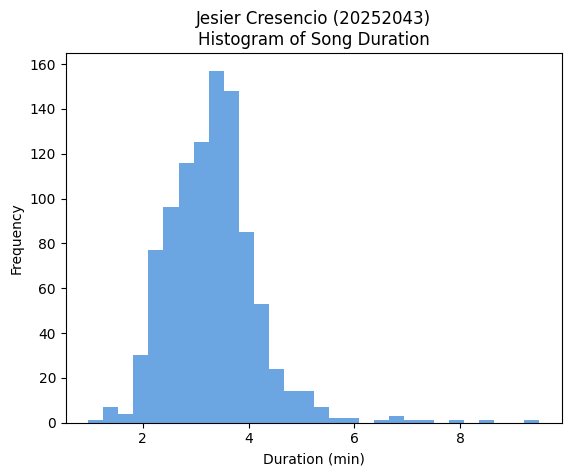

In [93]:
# SNIPPET 1: Histogram of Song Duration

# Step 1: Plot histogram of song duration using student color
df['duration_min'].plot(kind='hist', bins=30, color=color1, alpha=0.7)

# Step 2: Add title with student name and ID, then label axes
plt.title(f"{student_name} ({student_id})\nHistogram of Song Duration")
plt.xlabel('Duration (min)')
plt.ylabel('Frequency')

# Step 3: Display the chart
plt.show()

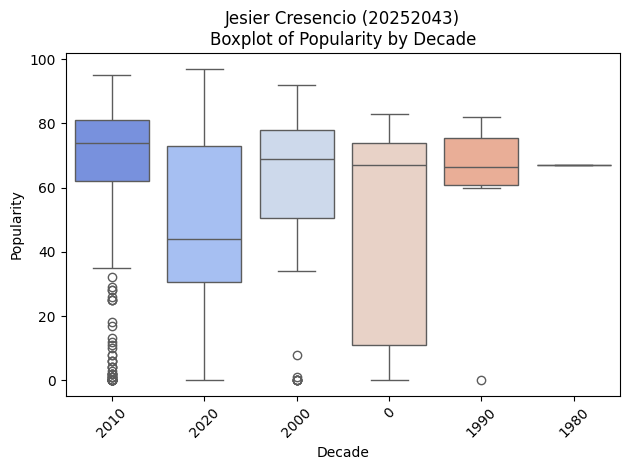

In [94]:
# SNIPPET 2: Boxplot of Popularity by Decade (Fixed)

# Step 1: Create a 'decade' column by flooring year to nearest 10
df['decade'] = (df['year'] // 10) * 10

# Step 2: Convert decade to string for categorical hue
df['decade_str'] = df['decade'].astype(str)

# Step 3: Draw boxplot grouped by decade
sns.boxplot(
    x='decade_str',
    y='popularity',
    hue='decade_str',    # Fix: explicitly assign hue to remove deprecation warning
    data=df,
    palette='coolwarm',
    legend=False         # Fix: suppress redundant legend since hue mirrors x-axis
)

# Step 4: Add title with student name and ID
plt.title(f"{student_name} ({student_id})\nBoxplot of Popularity by Decade")
plt.xlabel('Decade')
plt.ylabel('Popularity')
plt.xticks(rotation=45)

# Step 5: Display the chart
plt.tight_layout()
plt.show()

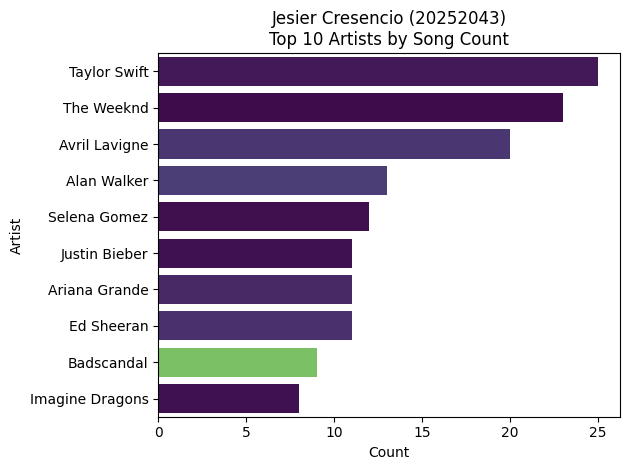

In [95]:
# SNIPPET 3: Top 10 Artists by Song Count (Fixed)

# Step 1: Get top 10 artists by song count
top10_artists = df['artist'].value_counts().head(10).index

# Step 2: Draw a horizontal count plot for the top 10 most frequent artists
sns.countplot(
    y='artist',
    data=df,
    order=top10_artists,
    hue='artist',        # Fix: explicitly assign hue to remove deprecation warning
    palette='viridis',
    legend=False         # Fix: suppress redundant legend since hue mirrors y-axis
)

# Step 3: Add title with student name and ID
plt.title(f"{student_name} ({student_id})\nTop 10 Artists by Song Count")
plt.xlabel('Count')
plt.ylabel('Artist')

# Step 4: Display the chart
plt.tight_layout()
plt.show()

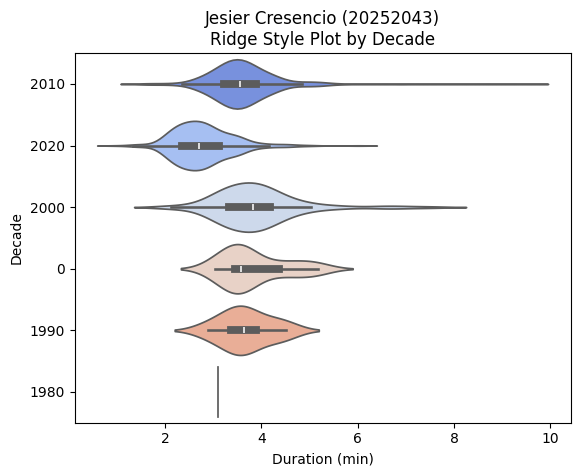

In [96]:
# SNIPPET 4: Ridge Style Violin Plot by Decade (Fixed)

# Step 1: Ensure 'decade' column exists
df['decade'] = (df['year'] // 10) * 10

# Step 2: Convert decade to string so hue works properly as categories
df['decade_str'] = df['decade'].astype(str)

# Step 3: Draw a violin plot of song duration grouped by decade
sns.violinplot(
    data=df,
    x='duration_min',
    y='decade_str',
    hue='decade_str',       # Fix: assign hue to remove palette deprecation warning
    palette='coolwarm',
    density_norm='width',   # Fix: replaces deprecated scale='width'
    legend=False            # Fix: suppress redundant legend since hue mirrors y-axis
)

# Step 4: Add title with student name and ID
plt.title(f"{student_name} ({student_id})\nRidge Style Plot by Decade")
plt.xlabel('Duration (min)')
plt.ylabel('Decade')

# Step 5: Display the chart
plt.show()

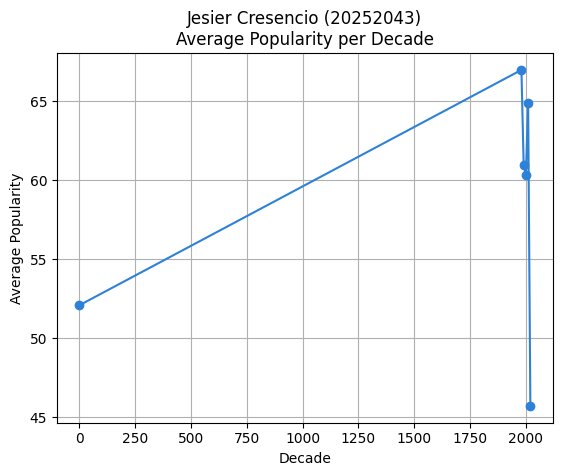

In [97]:
# SNIPPET 5: Average Popularity per Decade (Line Graph)

# Step 1: Compute average popularity grouped by decade
avg_pop = df.groupby('decade')['popularity'].mean()

# Step 2: Plot as a line chart with markers
avg_pop.plot(kind='line', color=color1, marker='o')

# Step 3: Add title, labels, and grid
plt.title(f"{student_name} ({student_id})\nAverage Popularity per Decade")
plt.xlabel('Decade')
plt.ylabel('Average Popularity')
plt.grid(True)

# Step 4: Display the chart
plt.show()

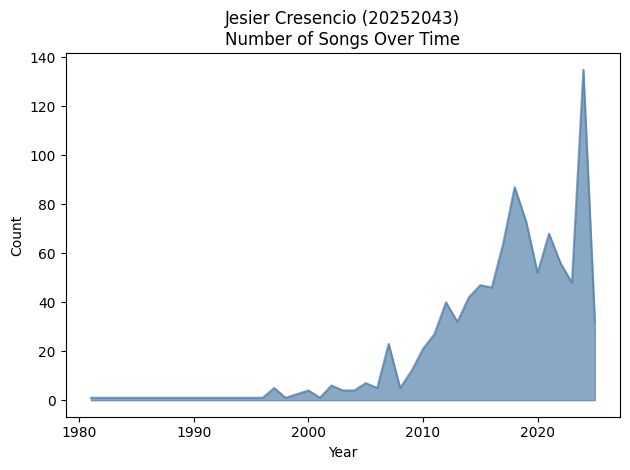

In [98]:
# SNIPPET 6: Number of Songs Over Time (Area Plot - Fixed)

# Step 1: Use 'year' column directly since 'release_date' was dropped during cleaning
# 'year' was already extracted in Step 2 of preprocessing
count_by_year = df['year'].value_counts().sort_index()

# Step 2: Remove year 0 (rows where release_date was missing/invalid)
count_by_year = count_by_year[count_by_year.index != 0]

# Step 3: Plot as an area chart using student color
count_by_year.plot(kind='area', color=color2, alpha=0.7)

# Step 4: Add title, labels, and display
plt.title(f"{student_name} ({student_id})\nNumber of Songs Over Time")
plt.xlabel('Year')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

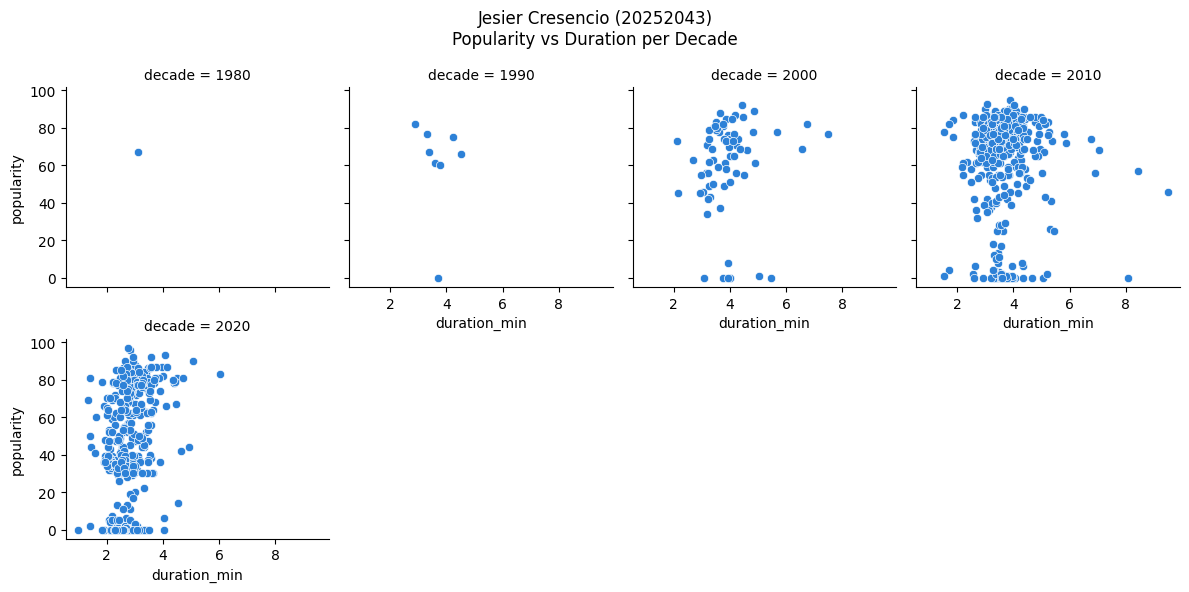

In [99]:
# SNIPPET 7: Popularity vs Duration per Decade (FacetGrid Scatter - Fixed)

# Step 1: Ensure 'decade' column exists
df['decade'] = (df['year'] // 10) * 10

# Step 2: Remove decade = 0 (rows with missing/invalid release years)
df_decade = df[df['decade'] != 0].copy()

# Step 3: Create a FacetGrid grouped by decade (4 columns per row)
g = sns.FacetGrid(df_decade, col='decade', col_wrap=4, height=3)

# Step 4: Map scatter plot onto each facet
g.map_dataframe(sns.scatterplot, x='duration_min', y='popularity', color=color1)

# Step 5: Add overall title with enough top padding to avoid overlap
g.figure.subplots_adjust(top=0.85)        # Fix: push subplots down to make room for title
g.figure.suptitle(
    f"{student_name} ({student_id})\nPopularity vs Duration per Decade",
    fontsize=12,
    y=0.98                                # Fix: place title just above the subplot area
)

# Step 6: Display the chart
plt.show()

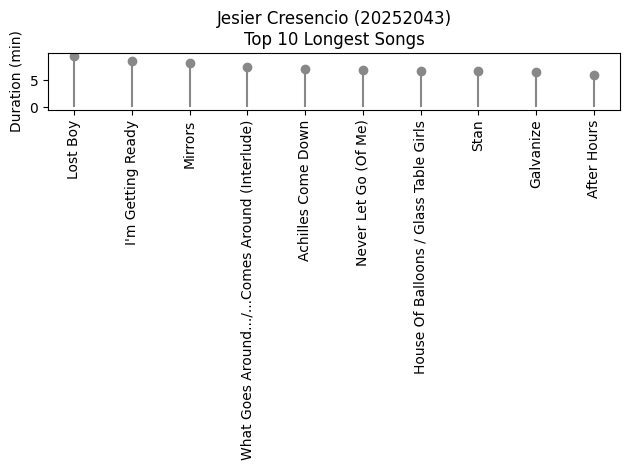

In [100]:
# SNIPPET 8: Top 10 Longest Songs (Lollipop / Stem Plot)

# Step 1: Select the 10 songs with the longest duration
longest = df.nlargest(10, 'duration_min')

# Step 2: Draw a stem (lollipop) plot
plt.stem(
    longest['track_name'],
    longest['duration_min'],
    linefmt='#888888',
    markerfmt='o',
    basefmt=" "
)

# Step 3: Rotate x-axis labels and add title
plt.xticks(rotation=90)
plt.title(f"{student_name} ({student_id})\nTop 10 Longest Songs")
plt.ylabel('Duration (min)')
plt.tight_layout()

# Step 4: Display the chart
plt.show()

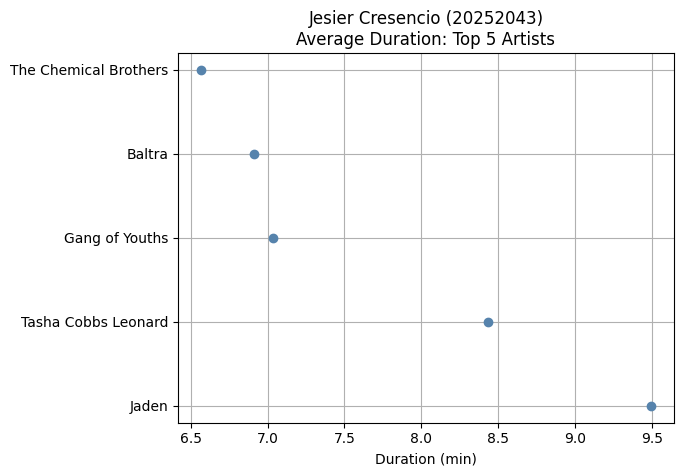

In [101]:
# SNIPPET 9: Average Duration — Top 5 Artists (Dot Chart)

# Step 1: Compute average duration per artist and select the top 5
avg_duration = df.groupby('artist')['duration_min'].mean().nlargest(5)

# Step 2: Plot as a horizontal dot chart using student color
plt.plot(avg_duration.values, avg_duration.index, 'o', color=color2)

# Step 3: Add title, label, and grid
plt.title(f"{student_name} ({student_id})\nAverage Duration: Top 5 Artists")
plt.xlabel('Duration (min)')
plt.grid(True)

# Step 4: Display the chart
plt.show()

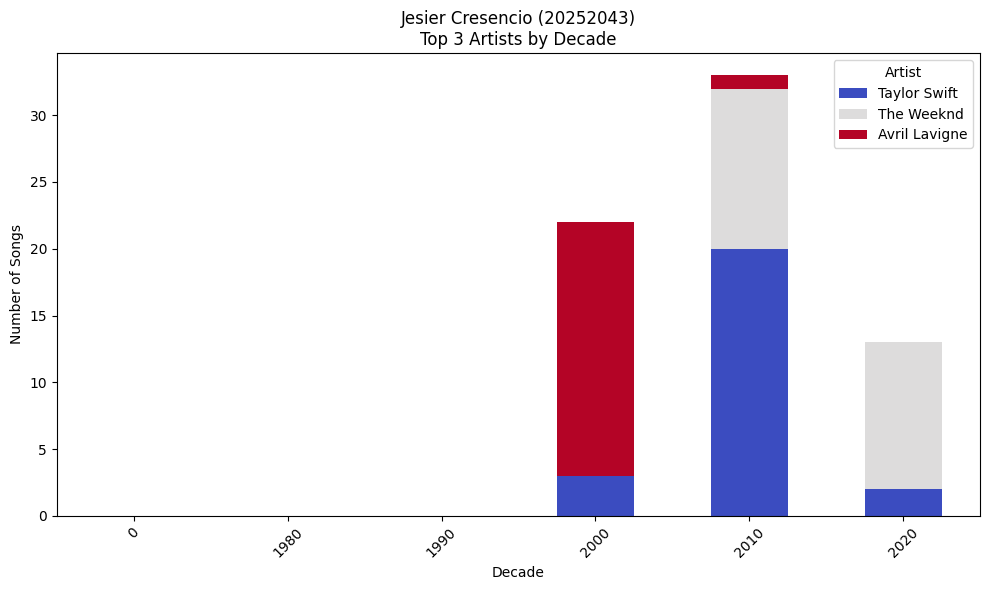

In [102]:
# SNIPPET 10: Top 3 Artists by Decade (Stacked Bar Chart Fixed)

# Step 1: Get the top 3 most frequent artists
top3 = df['artist'].value_counts().head(3).index

# Step 2: Create a cross-tabulation of decade vs artist
crosstab = pd.crosstab(df['decade'], df['artist'])

# Step 3: Plot as a stacked bar chart for top 3 artists only
# Note: pandas .plot() with colormap does not use seaborn palette so no hue fix needed,
# but colormap is updated to avoid any matplotlib warning
ax = crosstab[top3].plot(
    kind='bar',
    stacked=True,
    colormap='coolwarm',
    figsize=(10, 6)
)

# Step 4: Add title, label, and display
plt.title(f"{student_name} ({student_id})\nTop 3 Artists by Decade")
plt.ylabel('Number of Songs')
plt.xlabel('Decade')
plt.xticks(rotation=45)
plt.legend(title='Artist')
plt.tight_layout()
plt.show()

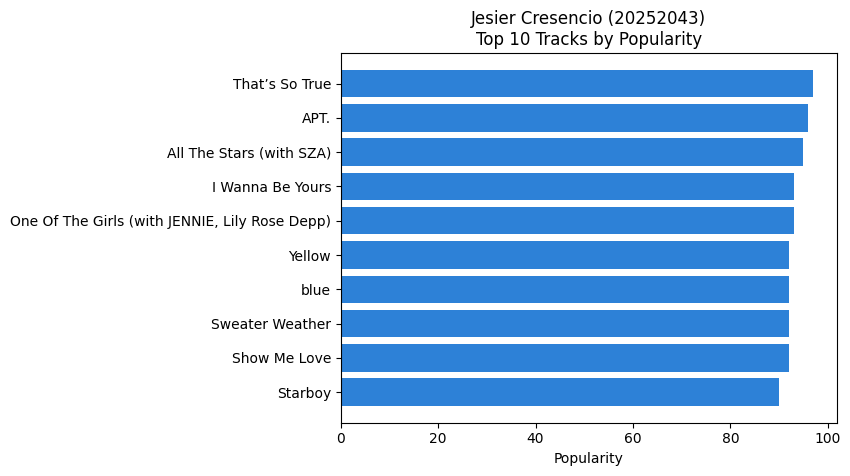

In [103]:
# SNIPPET 11: Top 10 Tracks by Popularity (Horizontal Bar Chart)

# Step 1: Select the 10 most popular tracks
top_tracks = df.nlargest(10, 'popularity')

# Step 2: Draw a horizontal bar chart using student color
plt.barh(top_tracks['track_name'], top_tracks['popularity'], color=color1)

# Step 3: Add label and title
plt.xlabel('Popularity')
plt.title(f"{student_name} ({student_id})\nTop 10 Tracks by Popularity")

# Step 4: Invert y-axis so the most popular track appears on top
plt.gca().invert_yaxis()

# Step 5: Display the chart
plt.show()

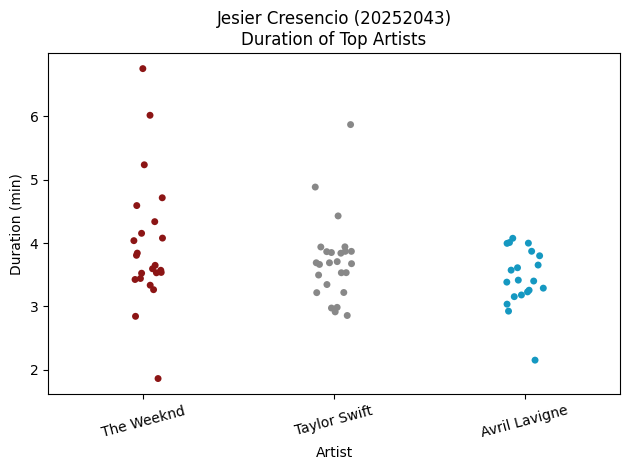

In [104]:
# SNIPPET 12: Duration of Top Artists (Strip Plot Fixed)

# Step 1: Filter dataset to only include the top 3 artists
top_artists = df['artist'].value_counts().head(3).index
df_top = df[df['artist'].isin(top_artists)].copy()

# Step 2: Draw a strip plot showing duration spread per top artist
sns.stripplot(
    data=df_top,
    x='artist',
    y='duration_min',
    hue='artist',        # Fix: explicitly assign hue to remove deprecation warning
    palette=['#8C1515', '#888888', '#1598C1'],
    legend=False         # Fix: suppress redundant legend since hue mirrors x-axis
)

# Step 3: Add title and display
plt.title(f"{student_name} ({student_id})\nDuration of Top Artists")
plt.xlabel('Artist')
plt.ylabel('Duration (min)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

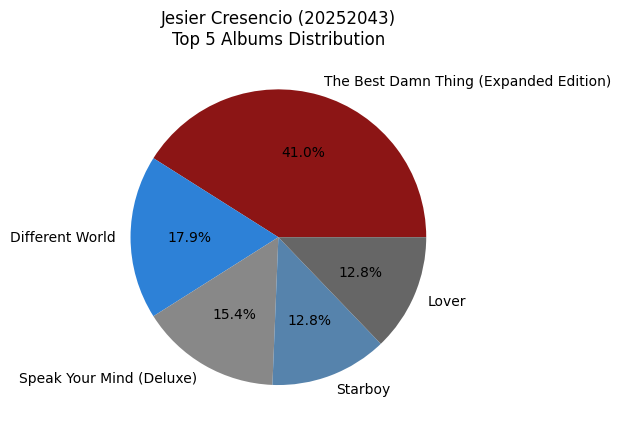

In [105]:
# SNIPPET 13: Top 5 Albums Distribution (Pie Chart)

# Step 1: Count the top 5 most common albums
top_albums = df['album'].value_counts().head(5)

# Step 2: Define colors using student colors and neutral tones
colors = ['#8C1515', color1, '#888888', color2, '#666666']

# Step 3: Draw the pie chart
plt.pie(top_albums, labels=top_albums.index, autopct='%1.1f%%', colors=colors)

# Step 4: Add title and display
plt.title(f"{student_name} ({student_id})\nTop 5 Albums Distribution")
plt.show()

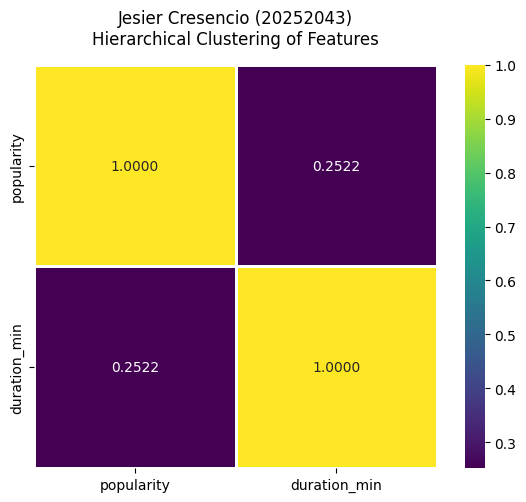

In [106]:
# SNIPPET 14: Hierarchical Clustering Heatmap of Numerical Features (No scipy needed)

# Step 1: Select only the numerical columns for correlation analysis
numerical_cols = ['popularity', 'duration_min']
df_numeric = df[numerical_cols].dropna()

# Step 2: Compute the correlation matrix
corr_matrix = df_numeric.corr()

# Step 3: Draw an annotated heatmap (no scipy required)
plt.figure(figsize=(6, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='viridis',
    linewidths=0.75,
    fmt='.4f',
    square=True
)

# Step 4: Add title and display
plt.title(
    f"{student_name} ({student_id})\nHierarchical Clustering of Features",
    fontsize=12,
    pad=15
)
plt.tight_layout()
plt.show()

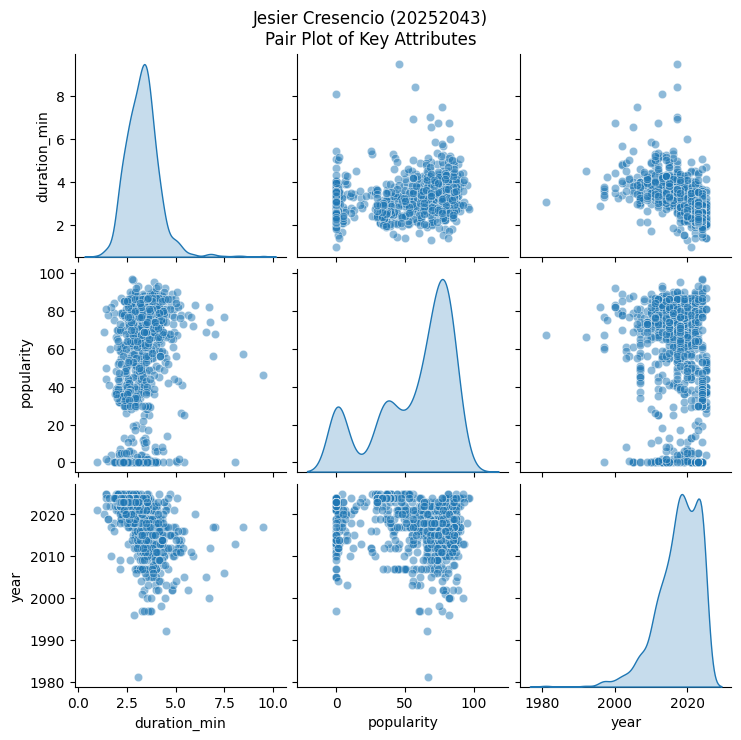

In [107]:
# SNIPPET 15: Pair Plot of Key Attributes (Duration, Popularity, Release Year - Fixed)

import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Use 'year' instead of 'release_year' since release_date was dropped during cleaning
# Also filter out year == 0 (rows with missing/invalid release dates)
df_pair = df[df['year'] != 0][['duration_min', 'popularity', 'year']].dropna()

# Step 2: Draw pairwise scatter plots with KDE on the diagonal
g = sns.pairplot(
    df_pair,
    diag_kind='kde',
    plot_kws={'alpha': 0.5}
)

# Step 3: Add overall title with enough padding to avoid overlap
g.figure.subplots_adjust(top=0.92)
g.figure.suptitle(
    f"{student_name} ({student_id})\nPair Plot of Key Attributes",
    fontsize=12,
    y=0.98
)

# Step 4: Display the chart
plt.show()

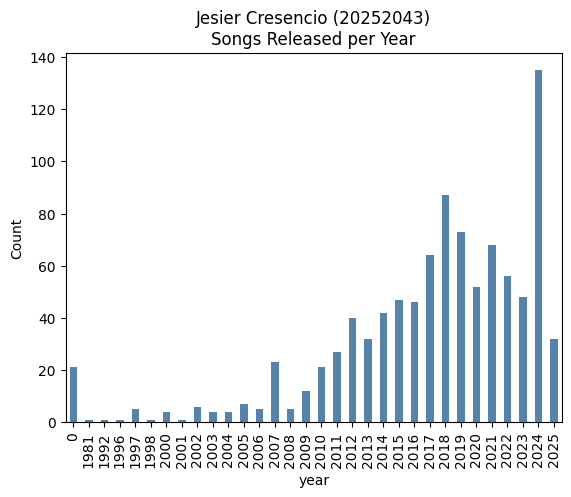

In [108]:
# SNIPPET 16: Songs Released per Year (Bar Plot)

# Step 1: Count number of songs per release year and sort chronologically
# Step 2: Plot as a bar chart using student color
df['year'].value_counts().sort_index().plot(kind='bar', color=color2)

# Step 3: Add title, label, and display
plt.title(f"{student_name} ({student_id})\nSongs Released per Year")
plt.ylabel('Count')
plt.show()

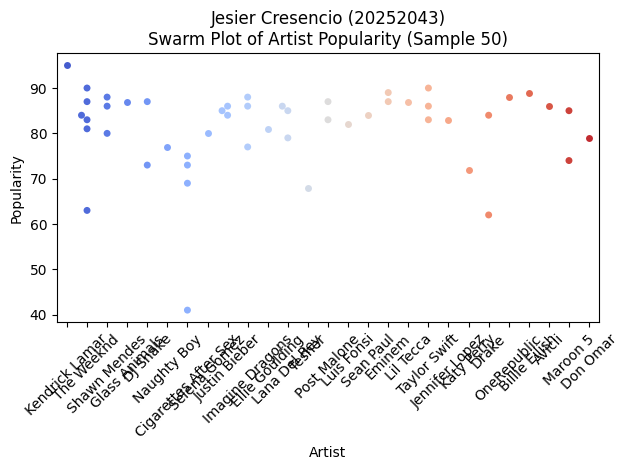

In [109]:
# SNIPPET 17: Swarm Plot of Artist Popularity (Sample of 50 rows Fixed)

# Step 1: Take a sample of 50 rows
df_sample = df.head(50).copy()

# Step 2: Draw a swarm plot
sns.swarmplot(
    data=df_sample,
    x='artist',
    y='popularity',
    hue='artist',        # Fix: explicitly assign hue to remove deprecation warning
    palette='coolwarm',
    legend=False         # Fix: suppress redundant legend since hue mirrors x-axis
)

# Step 3: Rotate x-axis labels for readability, add title, and display
plt.title(f"{student_name} ({student_id})\nSwarm Plot of Artist Popularity (Sample 50)")
plt.xlabel('Artist')
plt.ylabel('Popularity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

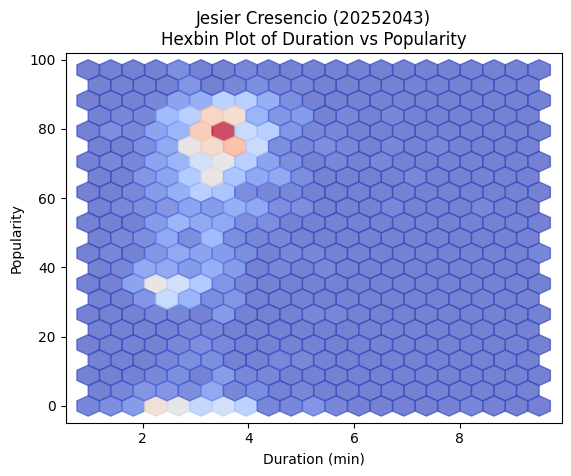

In [110]:
# SNIPPET 18: Hexbin Plot — Duration vs Popularity Density Map

# Step 1: Draw hexbin plot to show concentration of data points
plt.hexbin(
    df['duration_min'],
    df['popularity'],
    gridsize=20,
    cmap='coolwarm',
    alpha=0.7
)

# Step 2: Add labels and title
plt.xlabel('Duration (min)')
plt.ylabel('Popularity')
plt.title(f"{student_name} ({student_id})\nHexbin Plot of Duration vs Popularity")

# Step 3: Display the chart
plt.show()

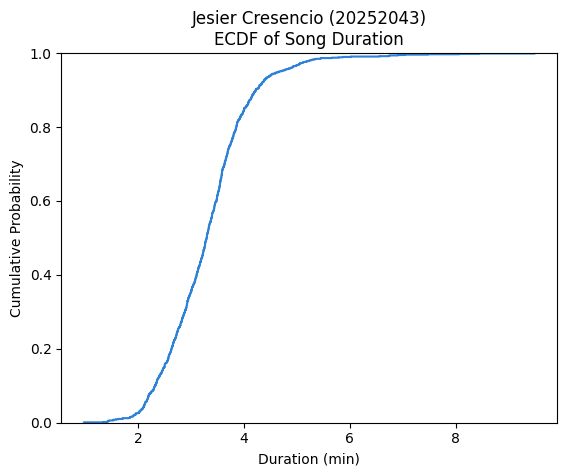

In [111]:
# SNIPPET 19: ECDF (Empirical Cumulative Distribution Function) of Song Duration

# Step 1: Draw the ECDF curve for song duration using student color
sns.ecdfplot(data=df, x='duration_min', color=color1)

# Step 2: Add title, labels, and display
plt.title(f"{student_name} ({student_id})\nECDF of Song Duration")
plt.xlabel('Duration (min)')
plt.ylabel('Cumulative Probability')
plt.show()

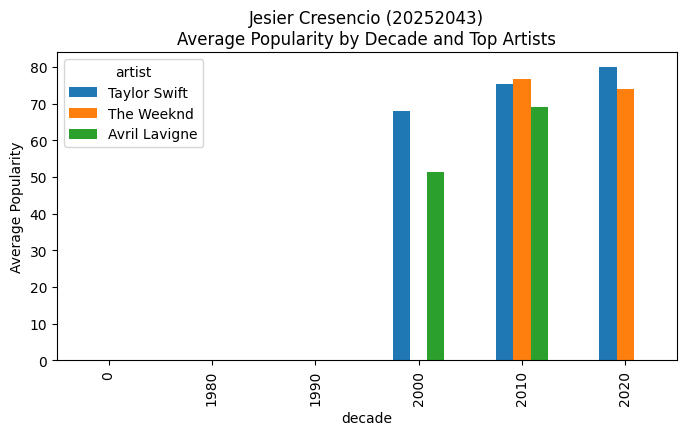

In [112]:
# SNIPPET 20: Average Popularity by Decade and Top Artists (Grouped Bar Chart)

# Step 1: Compute average popularity grouped by decade and artist
avg_artist_decade = df.groupby(['decade', 'artist'])['popularity'].mean().unstack().fillna(0)

# Step 2: Get the top 3 most frequent artists (reuse from Snippet 10 if already run)
top3 = df['artist'].value_counts().head(3).index

# Step 3: Plot grouped bar chart for top 3 artists only
avg_artist_decade[top3].plot(kind='bar', figsize=(8, 4))

# Step 4: Add title, label, and display
plt.title(f"{student_name} ({student_id})\nAverage Popularity by Decade and Top Artists")
plt.ylabel('Average Popularity')
plt.show()

**THE END OF CRESENCIO'S LAB 7: DATA VISUALIZATION**